In [60]:
import pandas as pd
import numpy as np

In [62]:
df = pd.read_csv("MSW93_OrderMSW93_FamilyMSW93_GenusMSW93_Species.csv")

In [64]:
df.head()

,MSW93_Order,MSW93_Family,MSW93_Genus,MSW93_Species,MSW93_Binomial,1-1_ActivityCycle,5-1_AdultBodyMass_g,8-1_AdultForearmLen_mm,13-1_AdultHeadBodyLen_mm,2-1_AgeatEyeOpening_d,...,26-6_GR_MinLong_dd,26-7_GR_MRLong_dd,27-1_HuPopDen_Min_n/km2,27-2_HuPopDen_Mean_n/km2,27-3_HuPopDen_5p_n/km2,27-4_HuPopDen_Change,28-1_Precip_Mean_mm,28-2_Temp_Mean_01degC,30-1_AET_Mean_mm,30-2_PET_Mean_mm
0,Rodentia,Muridae,Abditomys,latidens,Abditomys latidens,-999,268.0,-999.0,223.99,-999.0,...,120.78,120.88,93,93.00,93.0,0.09,316.00,180.00,1443.00,1557.00
1,Rodentia,Muridae,Abrawayaomys,ruschii,Abrawayaomys ruschii,-999,63.0,-999.0,-999.00,-999.0,...,-43.56,-42.04,5,21.21,7.0,0.06,107.06,209.10,1084.47,1402.39
2,Rodentia,Abrocomidae,Abrocoma,bennettii,Abrocoma bennettii,1,251.0,-999.0,-999.00,-999.0,...,-71.70,-70.55,0,63.15,1.0,0.07,20.44,17.66,213.09,1073.78
3,Rodentia,Abrocomidae,Abrocoma,boliviensis,Abrocoma boliviensis,-999,158.0,-999.0,-999.00,-999.0,...,-64.51,-64.00,5,29.24,5.0,0.04,82.63,175.55,1171.61,1487.33
4,Rodentia,Abrocomidae,Abrocoma,cinerea,Abrocoma cinerea,-999,194.0,-999.0,-999.00,-999.0,...,-70.60,-67.43,0,13.72,0.0,0.06,48.46,35.22,515.10,1257.35


In [66]:
# Split the data into features (X) and target (y)
X = df.drop('12-2_Terrestriality', axis=1)
y = df['12-2_Terrestriality']

In [68]:
df.head()

,MSW93_Order,MSW93_Family,MSW93_Genus,MSW93_Species,MSW93_Binomial,1-1_ActivityCycle,5-1_AdultBodyMass_g,8-1_AdultForearmLen_mm,13-1_AdultHeadBodyLen_mm,2-1_AgeatEyeOpening_d,...,26-6_GR_MinLong_dd,26-7_GR_MRLong_dd,27-1_HuPopDen_Min_n/km2,27-2_HuPopDen_Mean_n/km2,27-3_HuPopDen_5p_n/km2,27-4_HuPopDen_Change,28-1_Precip_Mean_mm,28-2_Temp_Mean_01degC,30-1_AET_Mean_mm,30-2_PET_Mean_mm
0,Rodentia,Muridae,Abditomys,latidens,Abditomys latidens,-999,268.0,-999.0,223.99,-999.0,...,120.78,120.88,93,93.00,93.0,0.09,316.00,180.00,1443.00,1557.00
1,Rodentia,Muridae,Abrawayaomys,ruschii,Abrawayaomys ruschii,-999,63.0,-999.0,-999.00,-999.0,...,-43.56,-42.04,5,21.21,7.0,0.06,107.06,209.10,1084.47,1402.39
2,Rodentia,Abrocomidae,Abrocoma,bennettii,Abrocoma bennettii,1,251.0,-999.0,-999.00,-999.0,...,-71.70,-70.55,0,63.15,1.0,0.07,20.44,17.66,213.09,1073.78
3,Rodentia,Abrocomidae,Abrocoma,boliviensis,Abrocoma boliviensis,-999,158.0,-999.0,-999.00,-999.0,...,-64.51,-64.00,5,29.24,5.0,0.04,82.63,175.55,1171.61,1487.33
4,Rodentia,Abrocomidae,Abrocoma,cinerea,Abrocoma cinerea,-999,194.0,-999.0,-999.00,-999.0,...,-70.60,-67.43,0,13.72,0.0,0.06,48.46,35.22,515.10,1257.35


In [70]:
print("All columns:", df.columns.tolist())

All columns: ['MSW93_Order', 'MSW93_Family', 'MSW93_Genus', 'MSW93_Species', 'MSW93_Binomial', '1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm', '13-1_AdultHeadBodyLen_mm', '2-1_AgeatEyeOpening_d', '3-1_AgeatFirstBirth_d', '18-1_BasalMetRate_mLO2hr', '5-2_BasalMetRateMass_g', '6-1_DietBreadth', '7-1_DispersalAge_d', '9-1_GestationLen_d', '12-1_HabitatBreadth', '22-1_HomeRange_km2', '22-2_HomeRange_Indiv_km2', '14-1_InterBirthInterval_d', '15-1_LitterSize', '16-1_LittersPerYear', '17-1_MaxLongevity_m', '5-3_NeonateBodyMass_g', '13-2_NeonateHeadBodyLen_mm', '21-1_PopulationDensity_n/km2', '10-1_PopulationGrpSize', '23-1_SexualMaturityAge_d', '10-2_SocialGrpSize', '24-1_TeatNumber', '12-2_Terrestriality', '6-2_TrophicLevel', '25-1_WeaningAge_d', '5-4_WeaningBodyMass_g', '13-3_WeaningHeadBodyLen_mm', 'References', '5-5_AdultBodyMass_g_EXT', '16-2_LittersPerYear_EXT', '5-6_NeonateBodyMass_g_EXT', '5-7_WeaningBodyMass_g_EXT', '26-1_GR_Area_km2', '26-2_GR_MaxLat_dd', '26-3

In [72]:
num_cols = df.select_dtypes(include="number").columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm', '13-1_AdultHeadBodyLen_mm', '2-1_AgeatEyeOpening_d', '3-1_AgeatFirstBirth_d', '18-1_BasalMetRate_mLO2hr', '5-2_BasalMetRateMass_g', '6-1_DietBreadth', '7-1_DispersalAge_d', '9-1_GestationLen_d', '12-1_HabitatBreadth', '22-1_HomeRange_km2', '22-2_HomeRange_Indiv_km2', '14-1_InterBirthInterval_d', '15-1_LitterSize', '16-1_LittersPerYear', '17-1_MaxLongevity_m', '5-3_NeonateBodyMass_g', '13-2_NeonateHeadBodyLen_mm', '21-1_PopulationDensity_n/km2', '10-1_PopulationGrpSize', '23-1_SexualMaturityAge_d', '10-2_SocialGrpSize', '24-1_TeatNumber', '12-2_Terrestriality', '6-2_TrophicLevel', '25-1_WeaningAge_d', '5-4_WeaningBodyMass_g', '13-3_WeaningHeadBodyLen_mm', '5-5_AdultBodyMass_g_EXT', '16-2_LittersPerYear_EXT', '5-6_NeonateBodyMass_g_EXT', '5-7_WeaningBodyMass_g_EXT', '26-1_GR_Area_km2', '26-2_GR_MaxLat_dd', '26-3_GR_MinLat_dd', '26-4_GR_MRLat_dd', '26-5_GR_MaxLong_dd', '26-6_GR_MinLong_dd', '26-7_GR_MRLong_dd'

In [123]:
num_cols = [c for c in num_cols if c in X_train.columns]
cat_cols = [c for c in cat_cols if c in X_train.columns]
print("Filtered numeric:", num_cols)
print("Filtered categorical:", cat_cols)

Filtered numeric: ['1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm', '13-1_AdultHeadBodyLen_mm', '2-1_AgeatEyeOpening_d', '3-1_AgeatFirstBirth_d', '18-1_BasalMetRate_mLO2hr', '5-2_BasalMetRateMass_g', '6-1_DietBreadth', '7-1_DispersalAge_d', '9-1_GestationLen_d', '12-1_HabitatBreadth', '22-1_HomeRange_km2', '22-2_HomeRange_Indiv_km2', '14-1_InterBirthInterval_d', '15-1_LitterSize', '16-1_LittersPerYear', '17-1_MaxLongevity_m', '5-3_NeonateBodyMass_g', '13-2_NeonateHeadBodyLen_mm', '21-1_PopulationDensity_n/km2', '10-1_PopulationGrpSize', '23-1_SexualMaturityAge_d', '10-2_SocialGrpSize', '24-1_TeatNumber', '6-2_TrophicLevel', '25-1_WeaningAge_d', '5-4_WeaningBodyMass_g', '13-3_WeaningHeadBodyLen_mm', '5-5_AdultBodyMass_g_EXT', '16-2_LittersPerYear_EXT', '5-6_NeonateBodyMass_g_EXT', '5-7_WeaningBodyMass_g_EXT', '26-1_GR_Area_km2', '26-2_GR_MaxLat_dd', '26-3_GR_MinLat_dd', '26-4_GR_MRLat_dd', '26-5_GR_MaxLong_dd', '26-6_GR_MinLong_dd', '26-7_GR_MRLong_dd', '27-1_HuPopD

Data Preprocessing Steps

Split Data for testing and training for Model 

In [76]:
from sklearn.model_selection import train_test_split

In [125]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [127]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="median")
cat_imp = SimpleImputer(strategy="most_frequent")

X_train_num = num_imp.fit_transform(X_train[num_cols])
X_test_num  = num_imp.transform(X_test[num_cols])

X_train_cat = cat_imp.fit_transform(X_train[cat_cols])
X_test_cat  = cat_imp.transform(X_test[cat_cols])



In [129]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat_enc = ohe.fit_transform(X_train[cat_cols])
X_test_cat_enc  = ohe.transform(X_test[cat_cols])



scaler = StandardScaler()
X_train_num_s = scaler.fit_transform(X_train_num)
X_test_num_s  = scaler.transform(X_test_num)

import numpy as np
X_train_pre = np.hstack([scaler.fit_transform(X_train[num_cols]), X_train_cat_enc])
X_test_pre = np.hstack([scaler.transform(X_test[num_cols]), X_test_cat_enc])


In [131]:
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_feature_names)


Train Random Forest Classifier

In [134]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pre, y_train)  


RandomForestClassifier(random_state=42)

Train and Get accuracy, confusion matrix of model

In [136]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_pre, y_train)

y_pred = rf.predict(X_test_pre)
print("RF accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

RF accuracy: 0.9049676025917927
Confusion matrix:
 [[379  10   2]
 [ 26 186  15]
 [ 10  25 273]]


In [137]:
print(X_train_pre.shape)  # Should output (n_samples, n_features)
print(len(y_train))      # Should output n_samples


(3703, 9721)
3703


In [140]:
# Assuming these variables are defined:
# X_train_pre, X_test_pre — numpy arrays of transformed data
# ohe — fitted OneHotEncoder
# scaler — fitted StandardScaler
# num_cols, cat_cols — original column name lists

import pandas as pd

# Build feature names list
num_feature_names = num_cols
cat_feature_names = list(ohe.get_feature_names_out(cat_cols))
all_features = num_feature_names + cat_feature_names

# Create DataFrames with correct column names
df_train_pre = pd.DataFrame(X_train_pre, columns=all_features)
df_train_pre['12-2_Terrestriality'] = y_train.values

df_test_pre = pd.DataFrame(X_test_pre, columns=all_features)
df_test_pre['12-2_Terrestriality'] = y_test.values

# Save to CSV
df_train_pre.to_csv("preprocessed_train.csv", index=False)
df_test_pre.to_csv("preprocessed_test.csv", index=False)

print("Saved preprocessed_train.csv and preprocessed_test.csv")


Saved preprocessed_train.csv and preprocessed_test.csv


Plot confusion Matrix

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

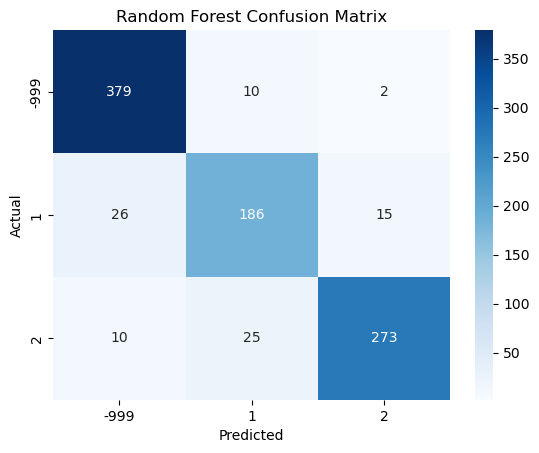

In [146]:


from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

y_pred_rf = rf.predict(X_test_pre)
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=rf.classes_, yticklabels=rf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


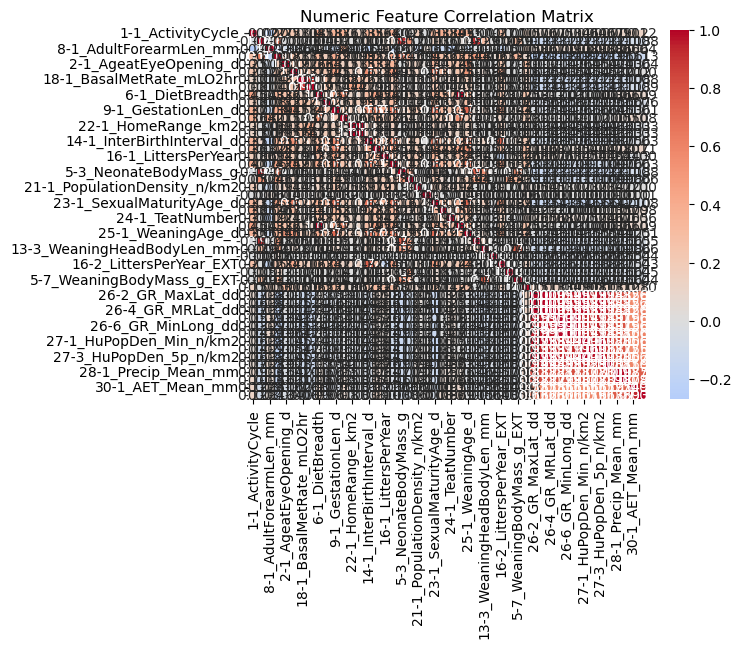

In [148]:
import numpy as np

corr = df_train_pre[num_feature_names].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Numeric Feature Correlation Matrix")
plt.show()


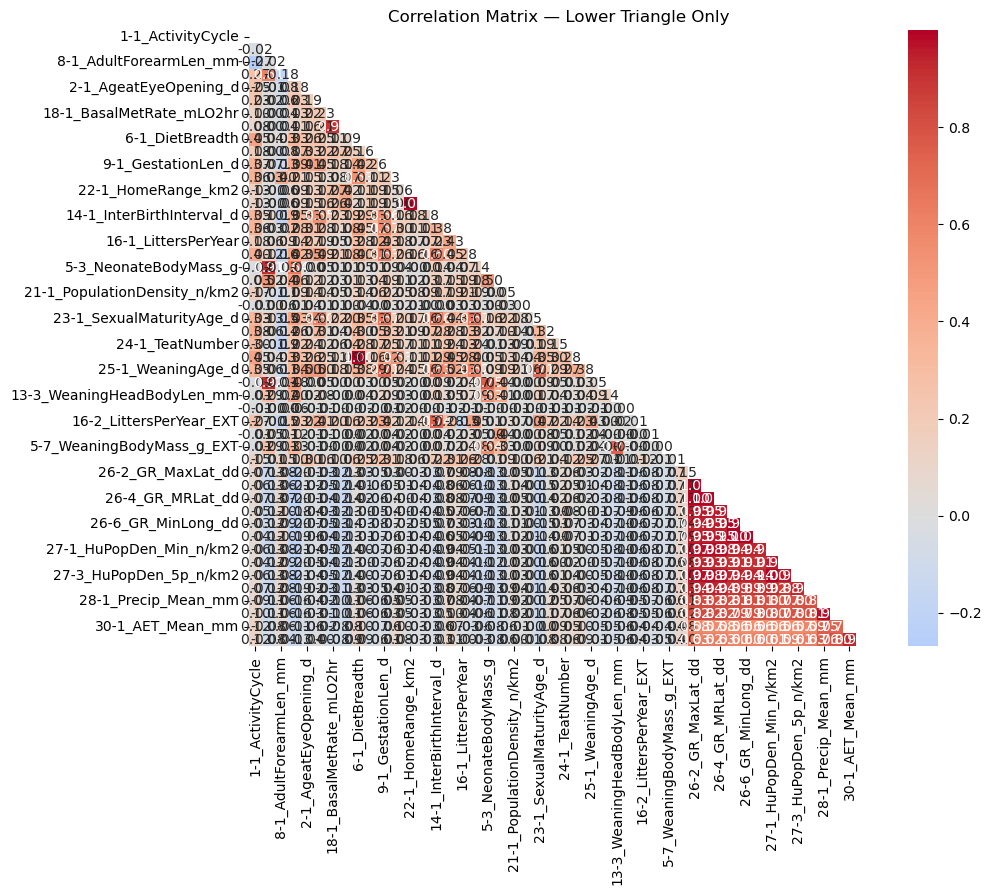

In [150]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_train_pre[num_feature_names].corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Lower Triangle Only")
plt.show()

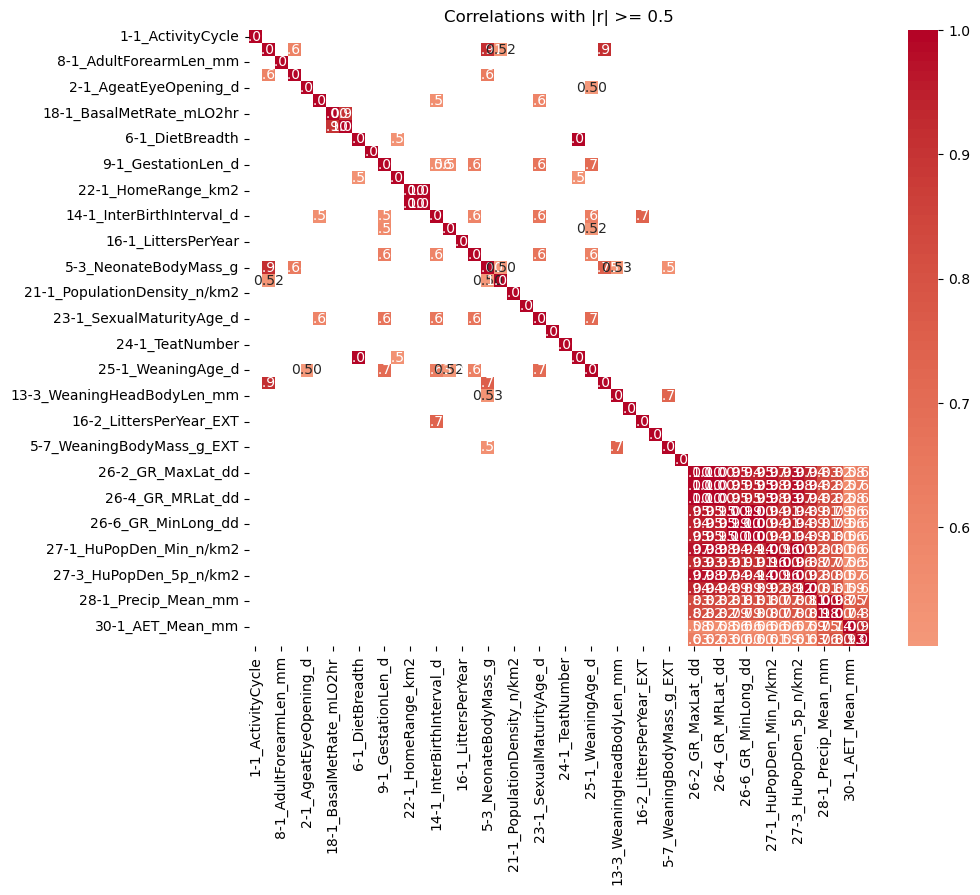

In [152]:
threshold = 0.5
mask = np.abs(corr) < threshold

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title(f"Correlations with |r| >= {threshold}")
plt.show()

Select features for correlation map plot

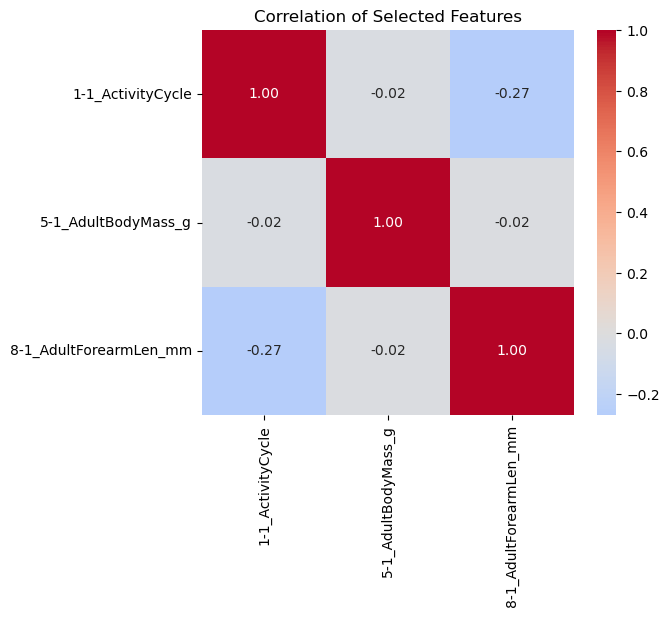

In [154]:
subset = ['1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm']  # example features
sub_corr = corr.loc[subset, subset]

plt.figure(figsize=(6, 5))
sns.heatmap(sub_corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0)
plt.title("Correlation of Selected Features")
plt.show()

Plot feature importance

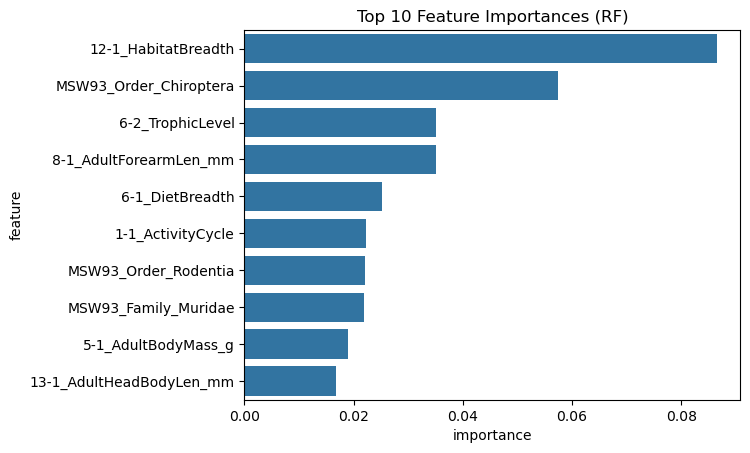

In [157]:
import pandas as pd

importances = rf.feature_importances_
feat_imp = pd.DataFrame({"feature": all_features, "importance": importances})
feat_imp = feat_imp.sort_values("importance", ascending=False).head(10)

sns.barplot(data=feat_imp, x="importance", y="feature")
plt.title("Top 10 Feature Importances (RF)")
plt.show()


Train Linear Regression Model

In [160]:
from sklearn.linear_model import LinearRegression

# Initialize and train model
model = LinearRegression()
model.fit(X_train_pre, y_train)

LinearRegression()

Get accuracy for linear regression model

In [161]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
y_pred = model.predict(X_test_pre)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")


Mean Squared Error: 3416.1061919181443
R-squared: 0.98601306225201


Train and get accuracy for the logistic regression model

In [168]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver="lbfgs", max_iter=1000)
model.fit(X_train_pre, y_train)
y_pred = model.predict(X_test_pre)
y_prob = model.predict_proba(X_test_pre)[:, 1]

In [170]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions
y_pred = model.predict(X_test_pre)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2}")


Mean Squared Error: 2162.0291576673867
R-squared: 0.9911477672125136


Explore missing values in file

In [173]:
df = pd.read_csv("MSW93_OrderMSW93_FamilyMSW93_GenusMSW93_Species.csv")

In [175]:
df.head()

,MSW93_Order,MSW93_Family,MSW93_Genus,MSW93_Species,MSW93_Binomial,1-1_ActivityCycle,5-1_AdultBodyMass_g,8-1_AdultForearmLen_mm,13-1_AdultHeadBodyLen_mm,2-1_AgeatEyeOpening_d,...,26-6_GR_MinLong_dd,26-7_GR_MRLong_dd,27-1_HuPopDen_Min_n/km2,27-2_HuPopDen_Mean_n/km2,27-3_HuPopDen_5p_n/km2,27-4_HuPopDen_Change,28-1_Precip_Mean_mm,28-2_Temp_Mean_01degC,30-1_AET_Mean_mm,30-2_PET_Mean_mm
0,Rodentia,Muridae,Abditomys,latidens,Abditomys latidens,-999,268.0,-999.0,223.99,-999.0,...,120.78,120.88,93,93.00,93.0,0.09,316.00,180.00,1443.00,1557.00
1,Rodentia,Muridae,Abrawayaomys,ruschii,Abrawayaomys ruschii,-999,63.0,-999.0,-999.00,-999.0,...,-43.56,-42.04,5,21.21,7.0,0.06,107.06,209.10,1084.47,1402.39
2,Rodentia,Abrocomidae,Abrocoma,bennettii,Abrocoma bennettii,1,251.0,-999.0,-999.00,-999.0,...,-71.70,-70.55,0,63.15,1.0,0.07,20.44,17.66,213.09,1073.78
3,Rodentia,Abrocomidae,Abrocoma,boliviensis,Abrocoma boliviensis,-999,158.0,-999.0,-999.00,-999.0,...,-64.51,-64.00,5,29.24,5.0,0.04,82.63,175.55,1171.61,1487.33
4,Rodentia,Abrocomidae,Abrocoma,cinerea,Abrocoma cinerea,-999,194.0,-999.0,-999.00,-999.0,...,-70.60,-67.43,0,13.72,0.0,0.06,48.46,35.22,515.10,1257.35


In [177]:
import pandas as pd
import numpy as np

In [179]:
df = pd.read_csv("MSW93_OrderMSW93_FamilyMSW93_GenusMSW93_Species.csv")

In [181]:
df.head()

,MSW93_Order,MSW93_Family,MSW93_Genus,MSW93_Species,MSW93_Binomial,1-1_ActivityCycle,5-1_AdultBodyMass_g,8-1_AdultForearmLen_mm,13-1_AdultHeadBodyLen_mm,2-1_AgeatEyeOpening_d,...,26-6_GR_MinLong_dd,26-7_GR_MRLong_dd,27-1_HuPopDen_Min_n/km2,27-2_HuPopDen_Mean_n/km2,27-3_HuPopDen_5p_n/km2,27-4_HuPopDen_Change,28-1_Precip_Mean_mm,28-2_Temp_Mean_01degC,30-1_AET_Mean_mm,30-2_PET_Mean_mm
0,Rodentia,Muridae,Abditomys,latidens,Abditomys latidens,-999,268.0,-999.0,223.99,-999.0,...,120.78,120.88,93,93.00,93.0,0.09,316.00,180.00,1443.00,1557.00
1,Rodentia,Muridae,Abrawayaomys,ruschii,Abrawayaomys ruschii,-999,63.0,-999.0,-999.00,-999.0,...,-43.56,-42.04,5,21.21,7.0,0.06,107.06,209.10,1084.47,1402.39
2,Rodentia,Abrocomidae,Abrocoma,bennettii,Abrocoma bennettii,1,251.0,-999.0,-999.00,-999.0,...,-71.70,-70.55,0,63.15,1.0,0.07,20.44,17.66,213.09,1073.78
3,Rodentia,Abrocomidae,Abrocoma,boliviensis,Abrocoma boliviensis,-999,158.0,-999.0,-999.00,-999.0,...,-64.51,-64.00,5,29.24,5.0,0.04,82.63,175.55,1171.61,1487.33
4,Rodentia,Abrocomidae,Abrocoma,cinerea,Abrocoma cinerea,-999,194.0,-999.0,-999.00,-999.0,...,-70.60,-67.43,0,13.72,0.0,0.06,48.46,35.22,515.10,1257.35


In [183]:

df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)

# Normalize column names
df.columns = df.columns.str.strip()

# Inspect columns
print("Columns:", df.columns.tolist())


Columns: ['MSW93_Order', 'MSW93_Family', 'MSW93_Genus', 'MSW93_Species', 'MSW93_Binomial', '1-1_ActivityCycle', '5-1_AdultBodyMass_g', '8-1_AdultForearmLen_mm', '13-1_AdultHeadBodyLen_mm', '2-1_AgeatEyeOpening_d', '3-1_AgeatFirstBirth_d', '18-1_BasalMetRate_mLO2hr', '5-2_BasalMetRateMass_g', '6-1_DietBreadth', '7-1_DispersalAge_d', '9-1_GestationLen_d', '12-1_HabitatBreadth', '22-1_HomeRange_km2', '22-2_HomeRange_Indiv_km2', '14-1_InterBirthInterval_d', '15-1_LitterSize', '16-1_LittersPerYear', '17-1_MaxLongevity_m', '5-3_NeonateBodyMass_g', '13-2_NeonateHeadBodyLen_mm', '21-1_PopulationDensity_n/km2', '10-1_PopulationGrpSize', '23-1_SexualMaturityAge_d', '10-2_SocialGrpSize', '24-1_TeatNumber', '12-2_Terrestriality', '6-2_TrophicLevel', '25-1_WeaningAge_d', '5-4_WeaningBodyMass_g', '13-3_WeaningHeadBodyLen_mm', 'References', '5-5_AdultBodyMass_g_EXT', '16-2_LittersPerYear_EXT', '5-6_NeonateBodyMass_g_EXT', '5-7_WeaningBodyMass_g_EXT', '26-1_GR_Area_km2', '26-2_GR_MaxLat_dd', '26-3_GR_

Plot heatmap of missing values

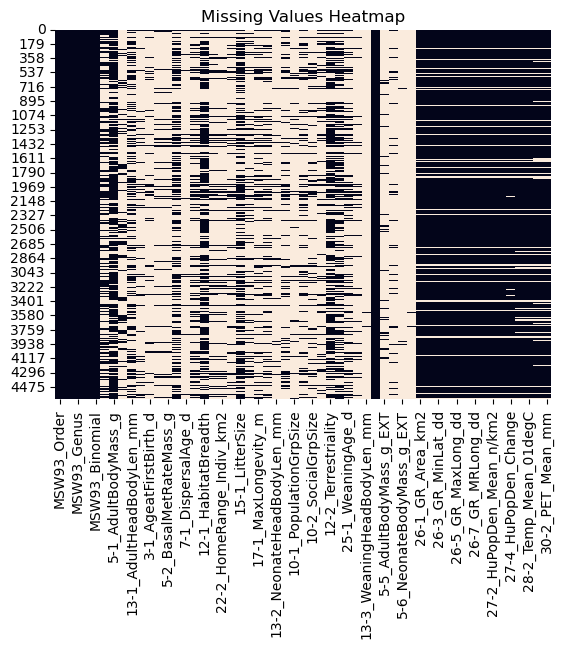

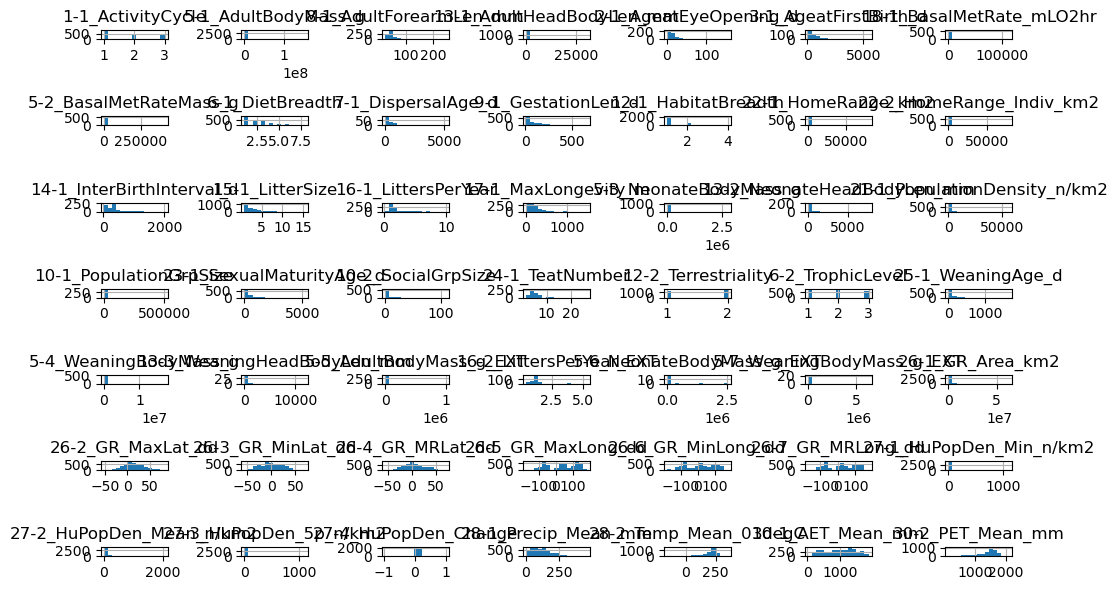

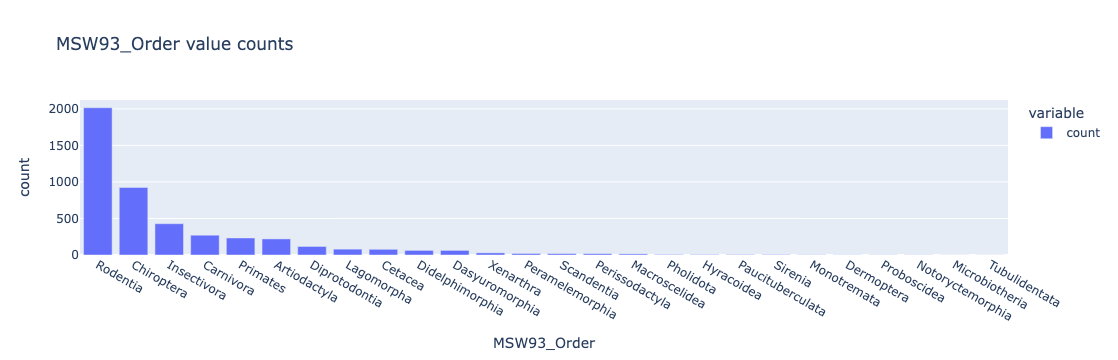

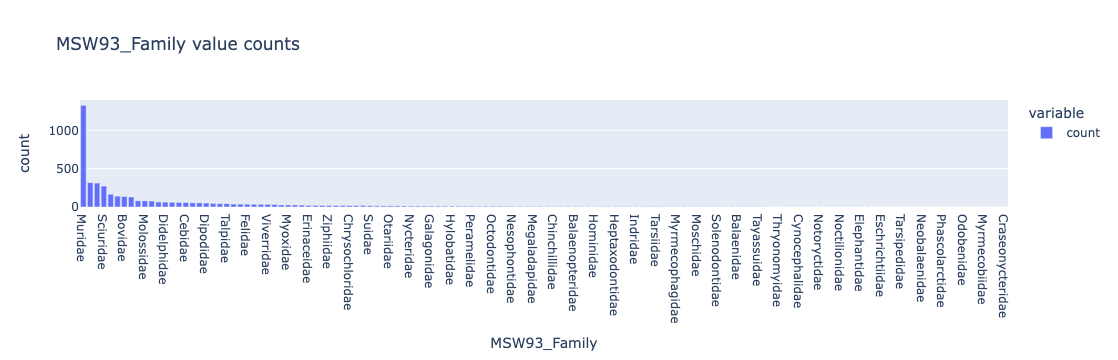

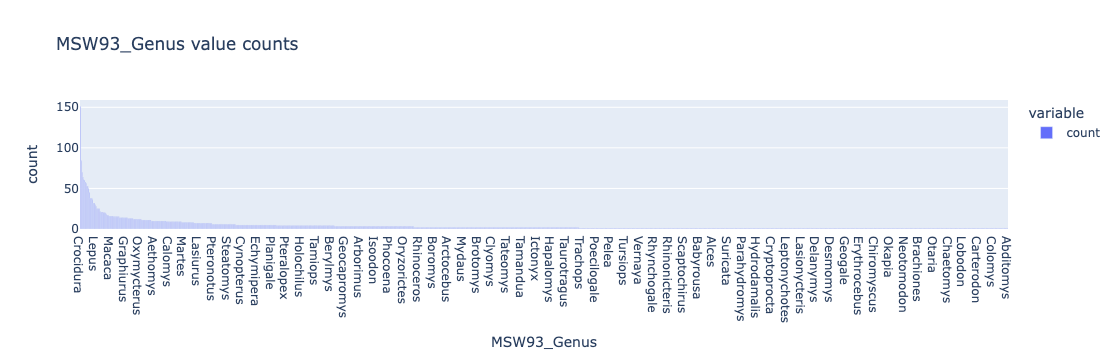

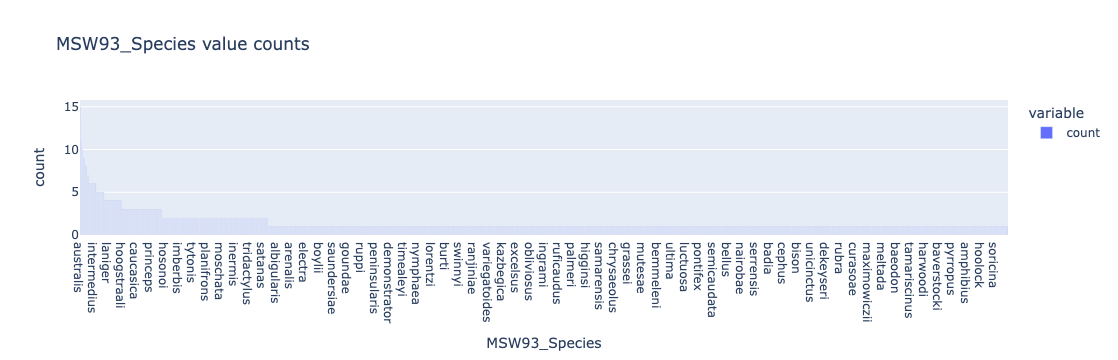

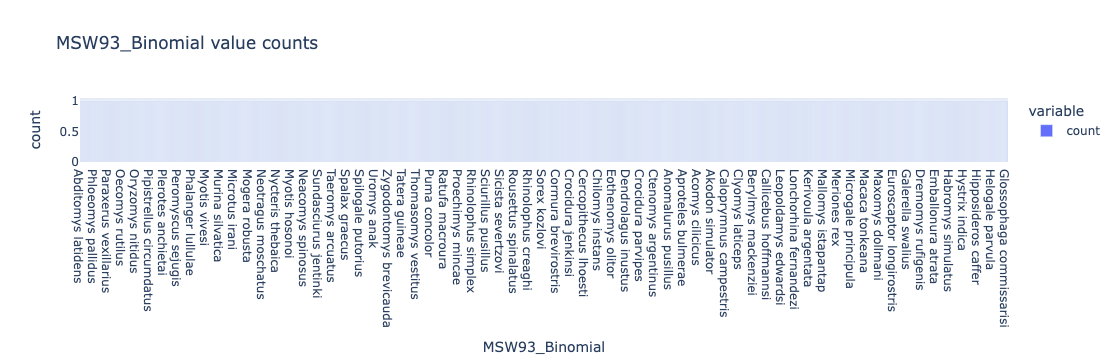

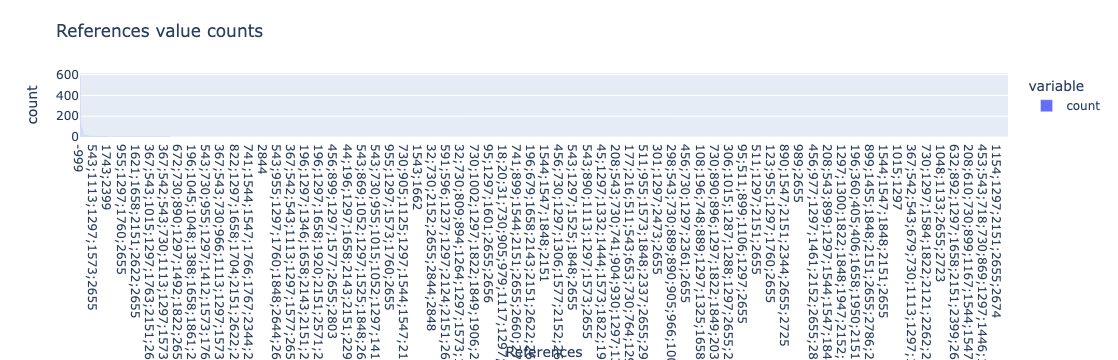

In [186]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Plot missing-value heatmap
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Numeric feature histograms
num_cols = df.select_dtypes(include="number").columns
df[num_cols].hist(bins=15, figsize=(10, 6))
plt.tight_layout()
plt.show()

# Categorical distribution charts
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    fig = px.bar(df[col].value_counts(), labels={'index': col, 'value': 'count'},
                 title=f"{col} value counts")
    fig.show()
